# Evaluation — claude-opus-4-8 (Anthropic)

## Experiment metadata

| | Batch | Whole-doc | PDF Direct | Vision Batch |
|---|---|---|---|---|
| **Prompt strategy** | 10 blocks/request · 3-block sliding context window | All blocks in 1 request · model sees full document | Raw PDF sent to Claude — no pdfplumber · Claude extracts + classifies | pdfplumber blocks + page PNG per page · Claude sees text + visual layout |
| **Input files** | `data/output/labeled/claude-opus-4-8_batch/sampleN.json` | `data/output/labeled/claude-opus-4-8_whole_doc/sampleN.json` | `data/output/labeled/claude-opus-4-8_pdf/sampleN.json` | `data/output/labeled/claude-opus-4-8_vision/sampleN.json` |
| **Regenerate** | `dmpbridge-experiment experiments/claude-opus-4-8-batch.yaml` | `dmpbridge-experiment experiments/claude-opus-4-8-wholedoc.yaml` | `dmpbridge-pdf --model claude-opus-4-8` | `dmpbridge-experiment experiments/claude-opus-4-8-vision.yaml` |
| **Provider** | Anthropic API | Anthropic API | Anthropic API (PDF vision) | Anthropic API (vision) |
| **Block granularity** | Line-level (pdfplumber) | Line-level (pdfplumber) | Paragraph-level (Claude reads PDF) | Line-level (pdfplumber) |
| **Bounding boxes** | Yes | Yes | No | Yes |
| **Page images** | No | No | No | `data/output/page_images/sampleN/` |

**Labels (5):** `title` · `section.title` · `section.description` · `question.text` · `answer.text`  
**Evaluation:** block-level accuracy + F1 against `data/input/ground_truth/sampleN_dmp.json` — no new files are written.

---

## Sections
1. Accuracy summary — per-sample table and batch vs whole-doc delta
2. Per-sample accuracy — side-by-side bar chart
3. Confusion matrix — raw counts and row-normalised recall
4. Precision / Recall / F1 — per label with batch vs whole-doc comparison
5. Mislabeled blocks — error breakdown and full detail table
6. PDF Direct — accuracy, block count, F1, and error analysis
7. **Vision Batch** — pdfplumber + page image; accuracy, confusion, F1, errors


In [1]:
MODEL_NAME    = "claude-opus-4-8"
MODEL_DISPLAY = "claude-opus-4-8"
COLOR_BATCH   = "#7c3aed"   # purple
COLOR_WHOLE   = "#c084fc"   # light purple
COLOR_PDF     = "#059669"   # green
COLOR_VISION  = "#0369a1"   # blue
CMAP_BATCH    = "Purples"
CMAP_WHOLE    = "RdPu"
CMAP_PDF      = "Greens"
CMAP_VISION   = "Blues"


In [2]:
from dmpbridge.evaluation.evaluate import (
    extract_gold, evaluate_sample, match,
    LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH,
    load_method, compute_f1_rows, gold_metrics,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "axes.edgecolor":"#555555", "axes.linewidth":0.8,
    "grid.color":"#dddddd",    "grid.linewidth":0.5,
    "text.color":"#111111",    "axes.labelcolor":"#111111",
    "xtick.color":"#111111",   "ytick.color":"#111111",
    "font.size":11, "axes.titlesize":13, "axes.labelsize":11,
    "xtick.labelsize":10, "ytick.labelsize":10,
    "legend.fontsize":10, "legend.frameon":True,
    "figure.dpi":120,
})

df_b, conf_b, errs_b = load_method(f"{MODEL_NAME}_batch")
df_w, conf_w, errs_w = load_method(f"{MODEL_NAME}_whole_doc")
df_p, conf_p, errs_p = load_method(f"{MODEL_NAME}_pdf")
df_v, conf_v, errs_v = load_method(f"{MODEL_NAME}_vision")

WHOLEDOC_AVAILABLE = df_w is not None and not df_w.empty
PDF_AVAILABLE      = df_p is not None and not df_p.empty
VISION_AVAILABLE   = df_v is not None and not df_v.empty

tc_b, tn_b = int(df_b["correct"].sum()), int(df_b["total"].sum())
print(f"Batch      ({MODEL_NAME}_batch)     : {tc_b}/{tn_b} ({tc_b/tn_b*100:.1f}%)")
if WHOLEDOC_AVAILABLE:
    tc_w, tn_w = int(df_w["correct"].sum()), int(df_w["total"].sum())
    print(f"Whole-doc  ({MODEL_NAME}_whole_doc) : {tc_w}/{tn_w} ({tc_w/tn_w*100:.1f}%)")
else:
    print(f"Whole-doc  : not available")
if PDF_AVAILABLE:
    tc_p, tn_p = int(df_p["correct"].sum()), int(df_p["total"].sum())
    print(f"PDF-direct ({MODEL_NAME}_pdf)       : {tc_p}/{tn_p} ({tc_p/tn_p*100:.1f}%)  [{tn_p} blocks vs {tn_b} pdfplumber]")
else:
    print(f"PDF-direct : not available — run: dmpbridge-pdf --model {MODEL_DISPLAY}")
if VISION_AVAILABLE:
    tc_v, tn_v = int(df_v["correct"].sum()), int(df_v["total"].sum())
    print(f"Vision     ({MODEL_NAME}_vision)    : {tc_v}/{tn_v} ({tc_v/tn_v*100:.1f}%)")
else:
    print(f"Vision     : not available — run: dmpbridge-experiment experiments/claude-opus-4-8-vision.yaml")


Batch      (claude-opus-4-8_batch)     : 703/741 (94.9%)
Whole-doc  (claude-opus-4-8_whole_doc) : 718/741 (96.9%)
PDF-direct (claude-opus-4-8_pdf)       : 193/203 (95.1%)  [203 blocks vs 741 pdfplumber]
Vision     (claude-opus-4-8_vision)    : 702/741 (94.7%)


## 1 — Accuracy summary

- **Accuracy** = blocks where the predicted label exactly matches gold.
- **Delta** = strategy accuracy minus batch. Positive = that strategy outperforms batch.
- A single bad sample can pull the overall number down — check the per-sample view next.


In [3]:
def print_table(df, label):
    hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
    print(f"  {label}")
    print("  " + "-" * len(hdr))
    for row in df.itertuples():
        print(f"  {row.sample:<12}  {row.total:>5}  {row.correct:>7}  "
              f"{row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
    print("  " + "-" * len(hdr))
    tn, tc = df["total"].sum(), df["correct"].sum()
    print(f"  {'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}\n")

print_table(df_b, f"Batch — {MODEL_NAME}")
if WHOLEDOC_AVAILABLE:
    print_table(df_w, f"Whole-doc — {MODEL_NAME}")
if PDF_AVAILABLE:
    print_table(df_p, f"PDF-direct — {MODEL_NAME}")
if VISION_AVAILABLE:
    print_table(df_v, f"Vision Batch — {MODEL_NAME}")

# ── Delta comparison across all available strategies ──────────────────────
base = df_b[["sample","accuracy"]].rename(columns={"accuracy":"batch"})
merged = base.copy()
extra_cols = []
if WHOLEDOC_AVAILABLE:
    merged = merged.merge(df_w[["sample","accuracy"]].rename(columns={"accuracy":"whole"}), on="sample")
    extra_cols.append(("whole", "Δ whole−batch"))
if PDF_AVAILABLE:
    merged = merged.merge(df_p[["sample","accuracy"]].rename(columns={"accuracy":"pdf"}), on="sample")
    extra_cols.append(("pdf", "Δ pdf−batch"))
if VISION_AVAILABLE:
    merged = merged.merge(df_v[["sample","accuracy"]].rename(columns={"accuracy":"vision"}), on="sample")
    extra_cols.append(("vision", "Δ vision−batch"))

for col, dcol in extra_cols:
    merged[dcol] = merged[col] - merged["batch"]

all_strats = ["batch"] + [c for c, _ in extra_cols]
all_dcols  = [d for _, d in extra_cols]
header = "  " + f"{'Sample':<12}" + "".join(f"  {s:>10}" for s in all_strats) + "".join(f"  {d:>16}" for d in all_dcols)
print(header)
print("  " + "-" * (len(header) - 2))
for _, r in merged.iterrows():
    row_str = f"  {r['sample']:<12}" + "".join(f"  {r[s]*100:>9.1f}%" for s in all_strats)
    for d in all_dcols:
        sign = '+' if r[d] >= 0 else ''
        row_str += f"  {sign}{r[d]*100:>14.1f}%"
    print(row_str)
tb = df_b['correct'].sum() / df_b['total'].sum()
ovr = f"  {'OVERALL':<12}  {tb*100:>9.1f}%"
for col, dcol in extra_cols:
    if col in merged.columns:
        tc_ = merged[col].mean()
        sign = '+' if (tc_ - merged['batch'].mean()) >= 0 else ''
        ovr += f"  {tc_*100:>9.1f}%"
print("  " + "-" * (len(header) - 2))
print(ovr)

# ── Gold-matched precision ────────────────────────────────────────────────
print("\n\n  ── Gold-matched precision (blocks that matched a manual-label item) ──\n")
print(f"  {'Strategy':<14}  {'Correct':>8}  {'Matched':>8}  {'All blocks':>11}  {'Gold prec':>10}  {'Block acc':>10}")
print("  " + "-" * 68)
avail = [("Batch", conf_b, df_b), ("Whole-doc", conf_w, df_w) if WHOLEDOC_AVAILABLE else None,
         ("PDF-direct", conf_p, df_p) if PDF_AVAILABLE else None,
         ("Vision Batch", conf_v, df_v) if VISION_AVAILABLE else None]
for item in avail:
    if item is None: continue
    strat_label, conf, df_strat = item
    correct, covered, matched = gold_metrics(conf)
    all_blocks = int(df_strat["total"].sum())
    gold_prec  = correct / matched    if matched    else 0
    block_acc  = correct / all_blocks if all_blocks else 0
    print(f"  {strat_label:<14}  {correct:>8}  {matched:>8}  {all_blocks:>11}  {gold_prec*100:>9.1f}%  {block_acc*100:>9.1f}%")


  Batch — claude-opus-4-8
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      149      23     86.6%  149/172
  sample3          69       69       0    100.0%  69/69
  sample4          78       78       0    100.0%  78/78
  sample5          86       80       6     93.0%  80/86
  sample6          29       21       8     72.4%  21/29
  sample7          17       16       1     94.1%  16/17
  sample8          59       59       0    100.0%  59/59
  sample9          85       85       0    100.0%  85/85
  sample10         68       68       0    100.0%  68/68
  -------------------------------------------------------
  TOTAL           741      703      38     94.9%  703/741

  Whole-doc — claude-opus-4-8
  -------------------------------------------------------
  sample1          78       78       0    100.0%  78/78
  sample2         172      166       6     96.5%  166/172
  sample3          69       69     

## 2 — Per-sample accuracy

Each cluster of bars = one sample. Strategies: Batch · Whole-doc · PDF-direct · Vision Batch.  
Large gaps between strategies on the same sample highlight where input representation matters most.


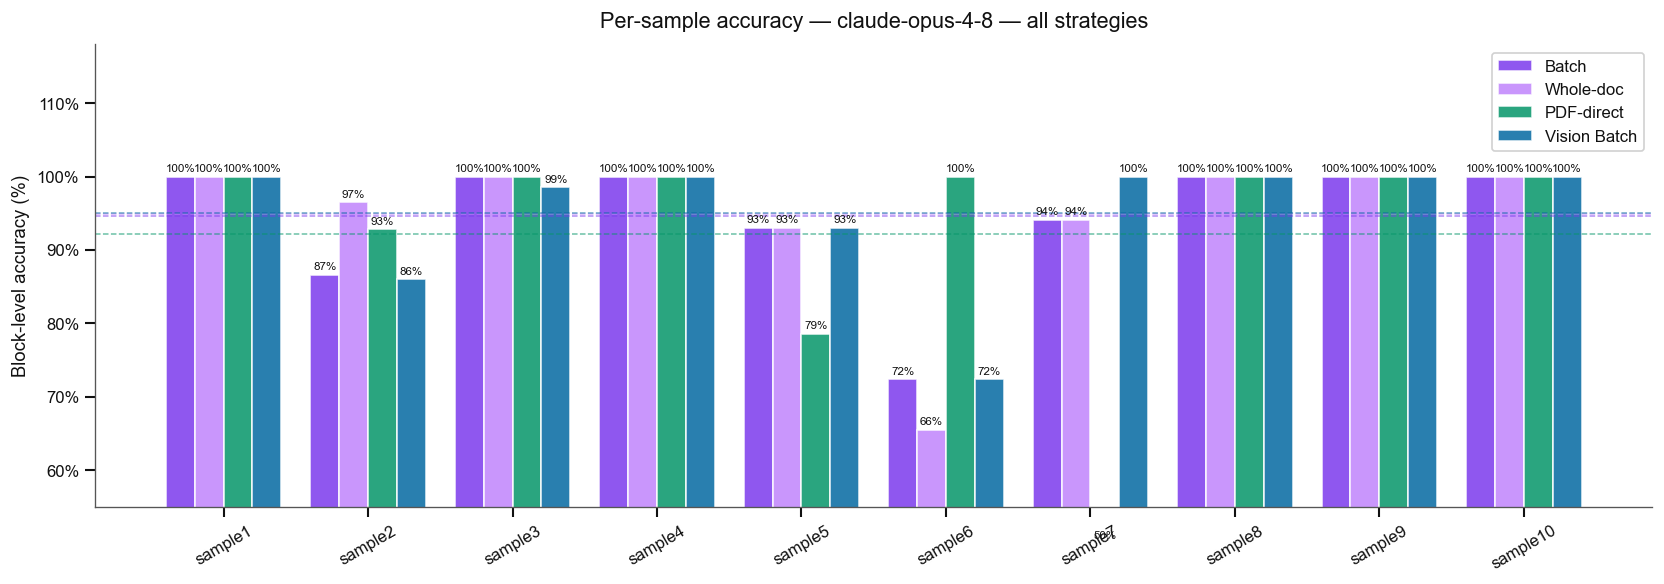

In [4]:
samples_ordered = df_b["sample"].tolist()
x = range(len(samples_ordered))

active_strats = [
    ("Batch",        df_b, COLOR_BATCH,  True),
    ("Whole-doc",    df_w, COLOR_WHOLE,  WHOLEDOC_AVAILABLE),
    ("PDF-direct",   df_p, COLOR_PDF,    PDF_AVAILABLE),
    ("Vision Batch", df_v, COLOR_VISION, VISION_AVAILABLE),
]
active_strats = [(lbl, df, col) for lbl, df, col, flag in active_strats if flag]
n_s = len(active_strats)
w   = 0.8 / n_s

fig, ax = plt.subplots(figsize=(14, 5))
for i, (lbl, df, color) in enumerate(active_strats):
    offset = (i - (n_s - 1) / 2) * w
    acc = df.set_index("sample").reindex(samples_ordered)["accuracy"] * 100
    bars = ax.bar([xi + offset for xi in x], acc, width=w,
                  label=lbl, color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, acc):
        if not pd.isna(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                    f"{v:.0f}%", ha="center", va="bottom", fontsize=7)
    avg = acc.mean()
    ax.axhline(avg, color=color, linestyle="--", linewidth=0.9, alpha=0.6)

ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
ax.set_ylim(55, 118); ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_NAME} — all strategies", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(framealpha=0.9)
sns.despine(); plt.tight_layout(); plt.show()


## 3 — Confusion matrix

Read **row by row**: each row = a true label, each column = what the model predicted.  
A perfect model has all mass on the diagonal.  
The most common failure mode is `question.text` being confused with `section.description` — both are funder-written text; the boundary is structural, not lexical.

Shown for: Batch · Whole-doc · Vision Batch (PDF-direct has its own matrix in Section 6).


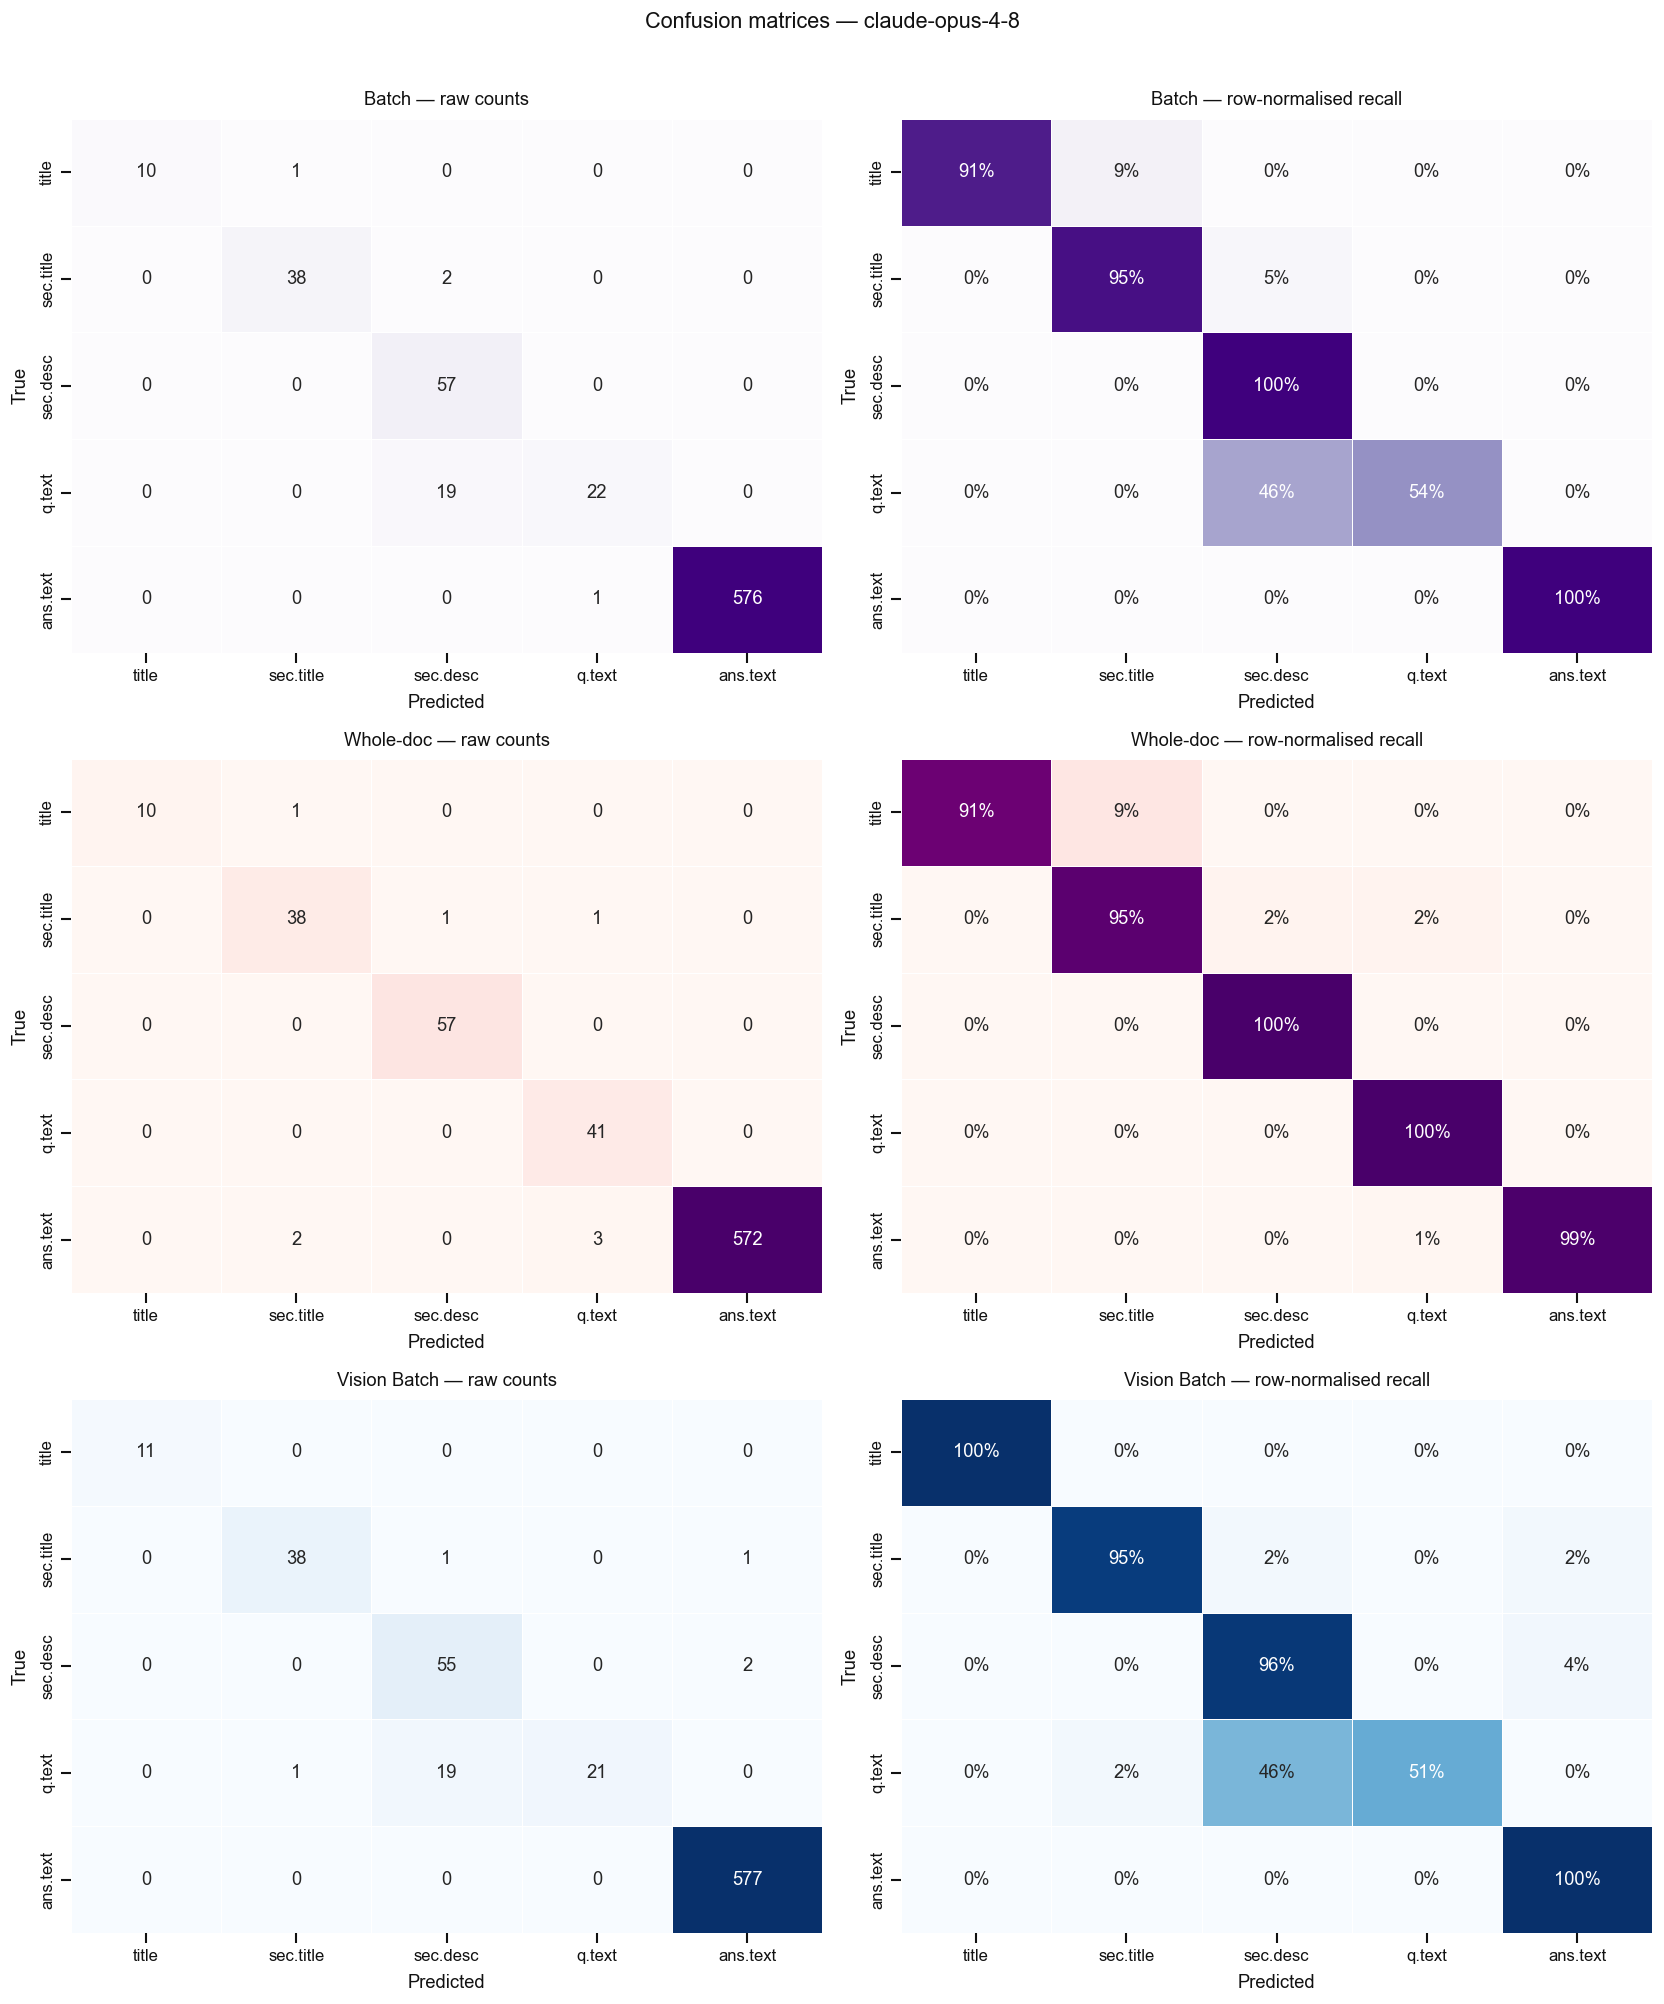

In [5]:
def conf_to_df(conf):
    m = pd.DataFrame(
        [[conf.get(t, {}).get(p, 0) for p in LABELS] for t in LABELS],
        index=SHORT, columns=SHORT)
    return m, m.div(m.sum(axis=1).replace(0, 1), axis=0)

mat_b, mat_bn = conf_to_df(conf_b)

conf_panels = [(mat_b, mat_bn, CMAP_BATCH, "Batch")]
if WHOLEDOC_AVAILABLE:
    mat_w, mat_wn = conf_to_df(conf_w)
    conf_panels.append((mat_w, mat_wn, CMAP_WHOLE, "Whole-doc"))
if VISION_AVAILABLE:
    mat_v2, mat_vn2 = conf_to_df(conf_v)
    conf_panels.append((mat_v2, mat_vn2, CMAP_VISION, "Vision Batch"))

n_rows = len(conf_panels)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5.5 * n_rows))
if n_rows == 1:
    axes = [axes]

for row_i, (mat_raw, mat_norm, cmap, title) in enumerate(conf_panels):
    for col_i, (mat, fmt, suffix) in enumerate([
        (mat_raw,  "d",   "raw counts"),
        (mat_norm, ".0%", "row-normalised recall"),
    ]):
        ax = axes[row_i][col_i]
        sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, linewidths=0.6,
                    linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                    vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
        ax.set_title(f"{title} — {suffix}", pad=8, fontsize=11)
        ax.set_xlabel("Predicted", labelpad=6)
        ax.set_ylabel("True", labelpad=6)

plt.suptitle(f"Confusion matrices — {MODEL_NAME}", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 4 — Precision / Recall / F1 per label

F1 balances precision and recall. Values below 80% indicate a reliability risk.  
The delta table shows per-label gain vs batch — the clearest signal for choosing a strategy.

Shown for: Batch · Whole-doc · Vision Batch (PDF-direct F1 is in Section 6).


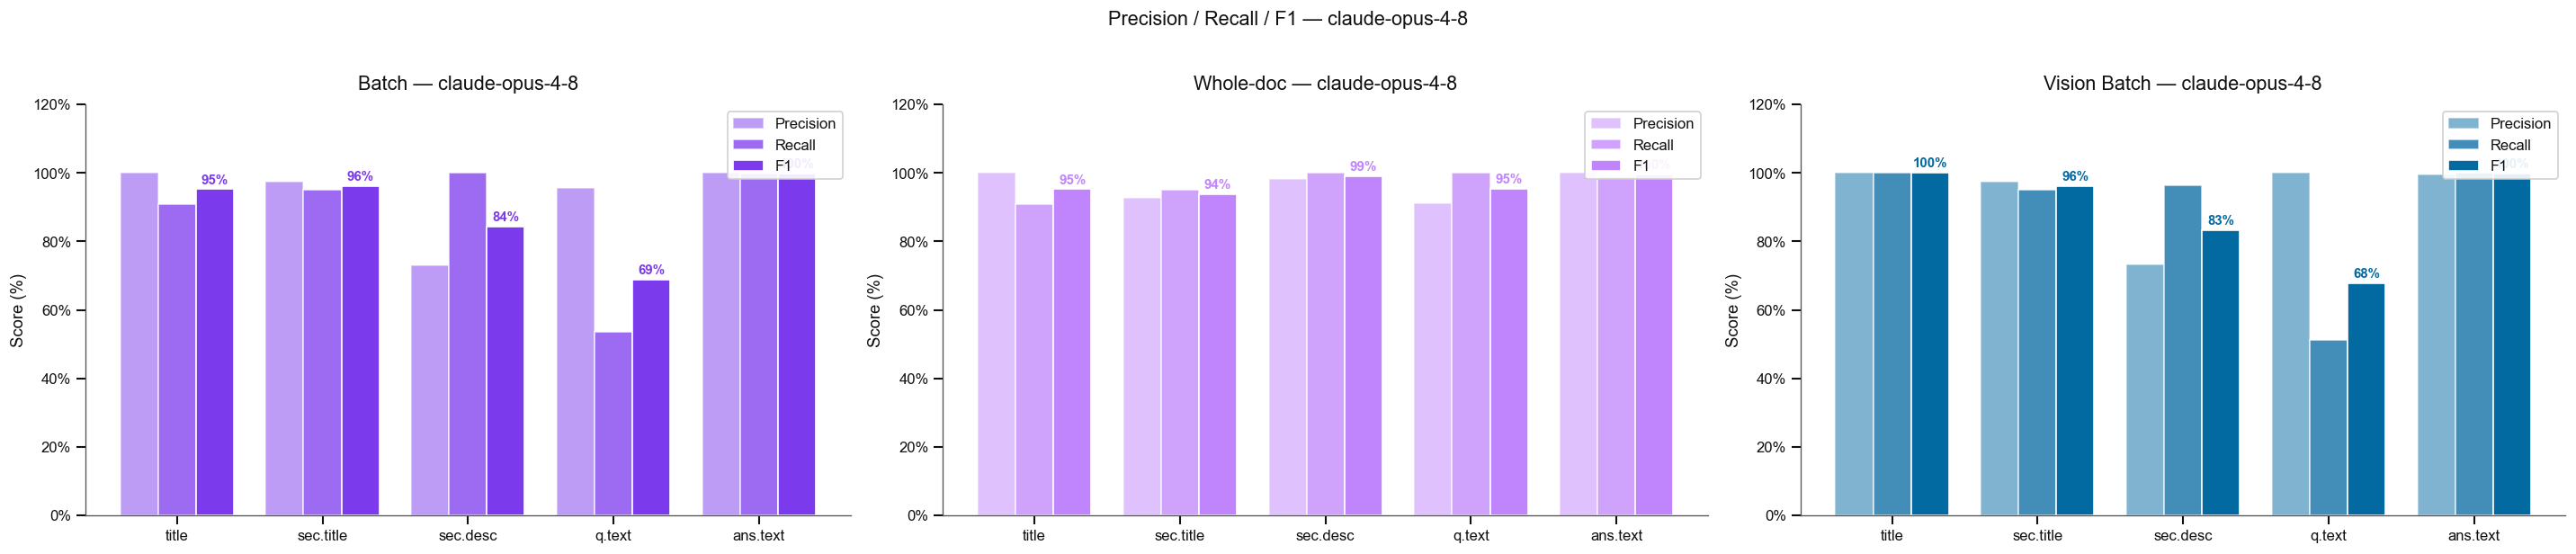

,batch,whole-doc,Δ whole,vision,Δ vision
label,,,,,
title,95.2%,95.2%,0.0%,100.0%,4.8%
section.title,96.2%,93.8%,-2.4%,96.2%,0.0%
section.description,84.4%,99.1%,14.7%,83.3%,-1.1%
question.text,68.8%,95.3%,26.6%,67.7%,-1.0%
answer.text,99.9%,99.6%,-0.3%,99.7%,-0.2%


In [6]:
df_f1_b = compute_f1_rows(conf_b)

f1_panels = [(df_f1_b, COLOR_BATCH, f"Batch — {MODEL_NAME}")]
if WHOLEDOC_AVAILABLE:
    df_f1_w = compute_f1_rows(conf_w)
    f1_panels.append((df_f1_w, COLOR_WHOLE, f"Whole-doc — {MODEL_NAME}"))
if VISION_AVAILABLE:
    df_f1_v2 = compute_f1_rows(conf_v)
    f1_panels.append((df_f1_v2, COLOR_VISION, f"Vision Batch — {MODEL_NAME}"))

n_p = len(f1_panels)
fig, axes = plt.subplots(1, n_p, figsize=(8 * n_p, 5))
if n_p == 1: axes = [axes]

for ax, (df_f1, color, title) in zip(axes, f1_panels):
    xi, bw = range(len(LABELS)), 0.26
    ax.bar([i - bw for i in xi], df_f1["precision"]*100, width=bw,
           label="Precision", color=color, alpha=0.5, edgecolor="white")
    ax.bar([i      for i in xi], df_f1["recall"]*100,    width=bw,
           label="Recall",    color=color, alpha=0.75, edgecolor="white")
    bars = ax.bar([i + bw for i in xi], df_f1["f1"]*100, width=bw,
                  label="F1", color=color, edgecolor="white")
    for bar, row in zip(bars, df_f1.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f"{row.f1*100:.0f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
    ax.set_ylim(0, 120); ax.set_ylabel("Score (%)"); ax.set_title(title, pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(loc="upper right", framealpha=0.9); sns.despine(ax=ax)

plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Delta table vs batch ──────────────────────────────────────────────────
delta_df = df_f1_b.set_index("label")[["f1"]].rename(columns={"f1":"batch"})
if WHOLEDOC_AVAILABLE:
    delta_df["whole-doc"] = df_f1_w.set_index("label")["f1"].values
    delta_df["Δ whole"]   = delta_df["whole-doc"] - delta_df["batch"]
if VISION_AVAILABLE:
    delta_df["vision"]    = df_f1_v2.set_index("label")["f1"].values
    delta_df["Δ vision"]  = delta_df["vision"] - delta_df["batch"]
display(delta_df.style.format("{:.1%}").background_gradient(
    subset=[c for c in delta_df.columns if not c.startswith("Δ")], cmap="Blues"))


## 5 — Mislabeled blocks

Use this table to distinguish **systematic** errors (same true→pred pair, many blocks) from **isolated** ones.  
Systematic patterns → prompt or strategy needs fixing. Isolated → acceptable noise.

Shown for: Batch · Whole-doc · Vision Batch.


In [7]:
def error_breakdown(df_err, label):
    print(f"  {label}: {len(df_err)} mislabeled blocks")
    if df_err.empty:
        print("  No errors.\n"); return
    bd = (df_err.groupby(["true","pred"]).size()
          .reset_index(name="count").sort_values("count", ascending=False))
    print(bd.to_string(index=False)); print()

error_breakdown(errs_b, f"Batch — {MODEL_NAME}")
if WHOLEDOC_AVAILABLE:
    error_breakdown(errs_w, f"Whole-doc — {MODEL_NAME}")
if VISION_AVAILABLE:
    error_breakdown(errs_v, f"Vision Batch — {MODEL_NAME}")


  Batch — claude-opus-4-8: 26 mislabeled blocks
         true                pred  count
question.text section.description     19
     no_match         answer.text      3
section.title section.description      2
  answer.text       question.text      1
        title       section.title      1

  Whole-doc — claude-opus-4-8: 11 mislabeled blocks
         true                pred  count
  answer.text       question.text      3
     no_match       section.title      3
  answer.text       section.title      2
section.title       question.text      1
section.title section.description      1
        title       section.title      1

  Vision Batch — claude-opus-4-8: 27 mislabeled blocks
               true                pred  count
      question.text section.description     19
           no_match         answer.text      3
section.description         answer.text      2
      question.text       section.title      1
      section.title         answer.text      1
      section.title section.

In [8]:
pd.set_option("display.max_colwidth", 100)
if not errs_b.empty:
    print("=== Batch errors ===")
    display(errs_b[["sample","page","true","pred","text"]])
if WHOLEDOC_AVAILABLE and not errs_w.empty:
    print("\n=== Whole-doc errors ===")
    display(errs_w[["sample","page","true","pred","text"]])
if VISION_AVAILABLE and not errs_v.empty:
    print("\n=== Vision Batch errors ===")
    display(errs_v[["sample","page","true","pred","text"]])


=== Batch errors ===


,sample,page,true,pred,text
0,sample2,2,question.text,section.description,"This should include, where appropriate:"
1,sample2,2,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access the data
2,sample2,2,question.text,section.description,and under what conditions;
3,sample2,2,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time the data
4,sample2,2,question.text,section.description,will be available and any anticipated delay to data access after research findings are published;
5,sample2,2,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to access"
6,sample2,2,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-distribution,..."
7,sample2,2,question.text,section.description,"for the production of derivatives, including guidance for how data and data products should be"
8,sample2,2,question.text,section.description,cited;
9,sample2,2,question.text,section.description,"any resources and capabilities (equipment, connections, systems, software, expertise, etc.)"



=== Whole-doc errors ===


,sample,page,true,pred,text
0,sample2,1,answer.text,question.text,"Roles & Responsibilities. For the proposed research, Director Samuel Stupp with help from the"
1,sample2,2,section.title,question.text,preservation;
2,sample2,4,answer.text,question.text,Data Repositories. Senior investigators typically archive relevant data using their own group se...
3,sample2,4,answer.text,question.text,"Data Volume. Generally, the volume of data generated by CBES researchers should not prohibit their"
4,sample2,5,section.title,section.description,data.
5,sample6,1,answer.text,section.title,"1. Types of data. The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,sample6,1,no_match,section.title,2. Data and metadata standards. The PI’s research group will adopt the longstanding
7,sample6,1,answer.text,section.title,3. Policies for access and sharing. Interested parties will be able to request data and codes at
8,sample6,1,no_match,section.title,"4. Policies and provisions for re-use, re-distribution. Simulation data will in essence grow to"
9,sample6,1,no_match,section.title,5. Plans for archiving and preservation of access. Local data will be archived on the group’s



=== Vision Batch errors ===


,sample,page,true,pred,text
0,sample2,2,question.text,section.title,Data Sharing and Data Preservation. A description of the plans for data sharing and preservation.
1,sample2,2,question.text,section.description,"This should include, where appropriate:"
2,sample2,2,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access the data
3,sample2,2,question.text,section.description,and under what conditions;
4,sample2,2,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time the data
5,sample2,2,question.text,section.description,will be available and any anticipated delay to data access after research findings are published;
6,sample2,2,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to access"
7,sample2,2,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-distribution,..."
8,sample2,2,question.text,section.description,"for the production of derivatives, including guidance for how data and data products should be"
9,sample2,2,question.text,section.description,cited;


---

## 6 — Option A: PDF Direct

Instead of using pdfplumber to extract text blocks, the raw PDF is sent directly to Claude.  
Claude sees the actual visual layout (fonts, indentation, columns) and both **extracts and classifies** the document in a single API call.

**Key difference:** Claude produces paragraph-level blocks (~27% of the pdfplumber count).  
Bounding boxes are not available — this approach cannot drive the viewer overlay.

**Regenerate:** `dmpbridge-pdf --model claude-opus-4-8`

In [9]:
if PDF_AVAILABLE:
    # ── All-strategy accuracy comparison ─────────────────────────────────
    print("=== Strategy comparison ===\n")
    rows_cmp = [
        ("Batch",        df_b),
        ("Whole-doc",    df_w),
        ("PDF-direct",   df_p),
    ]
    if VISION_AVAILABLE:
        rows_cmp.append(("Vision Batch", df_v))
    hdr = f"  {'Strategy':<14}  {'Blocks':>8}  {'Correct':>8}  {'Accuracy':>9}"
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for label, df in rows_cmp:
        if df is None or df.empty: continue
        tc_ = int(df["correct"].sum())
        tn_ = int(df["total"].sum())
        print(f"  {label:<14}  {tn_:>8}  {tc_:>8}  {tc_/tn_*100:>8.1f}%")

    # ── Block count per sample (pdfplumber vs pdf-direct) ────────────────
    print("\n=== Block count per sample ===\n")
    hdr2 = f"  {'Sample':<12}  {'Batch/WD':>9}  {'PDF-direct':>11}  {'Ratio':>7}"
    print(hdr2)
    print("  " + "-" * (len(hdr2) - 2))
    for _, rb in df_b.iterrows():
        s   = rb["sample"]
        nb_ = int(rb["total"])
        rp  = df_p[df_p["sample"] == s]
        np_ = int(rp["total"].iloc[0]) if not rp.empty else 0
        print(f"  {s:<12}  {nb_:>9}  {np_:>11}  {np_/nb_*100:>6.0f}%")
    print("  " + "-" * (len(hdr2) - 2))
    print(f"  {'TOTAL':<12}  {tn_b:>9}  {tn_p:>11}  {tn_p/tn_b*100:>6.0f}%")
else:
    print("PDF-direct data not available — run: dmpbridge-pdf --model", MODEL_DISPLAY)


=== Strategy comparison ===

  Strategy          Blocks   Correct   Accuracy
  ---------------------------------------------
  Batch                741       703      94.9%
  Whole-doc            741       718      96.9%
  PDF-direct           203       193      95.1%
  Vision Batch         741       702      94.7%

=== Block count per sample ===

  Sample         Batch/WD   PDF-direct    Ratio
  ---------------------------------------------
  sample1              78           32      41%
  sample2             172           42      24%
  sample3              69           23      33%
  sample4              78           15      19%
  sample5              86           28      33%
  sample6              29           11      38%
  sample7              17            2      12%
  sample8              59           19      32%
  sample9              85           14      16%
  sample10             68           17      25%
  ---------------------------------------------
  TOTAL               741 

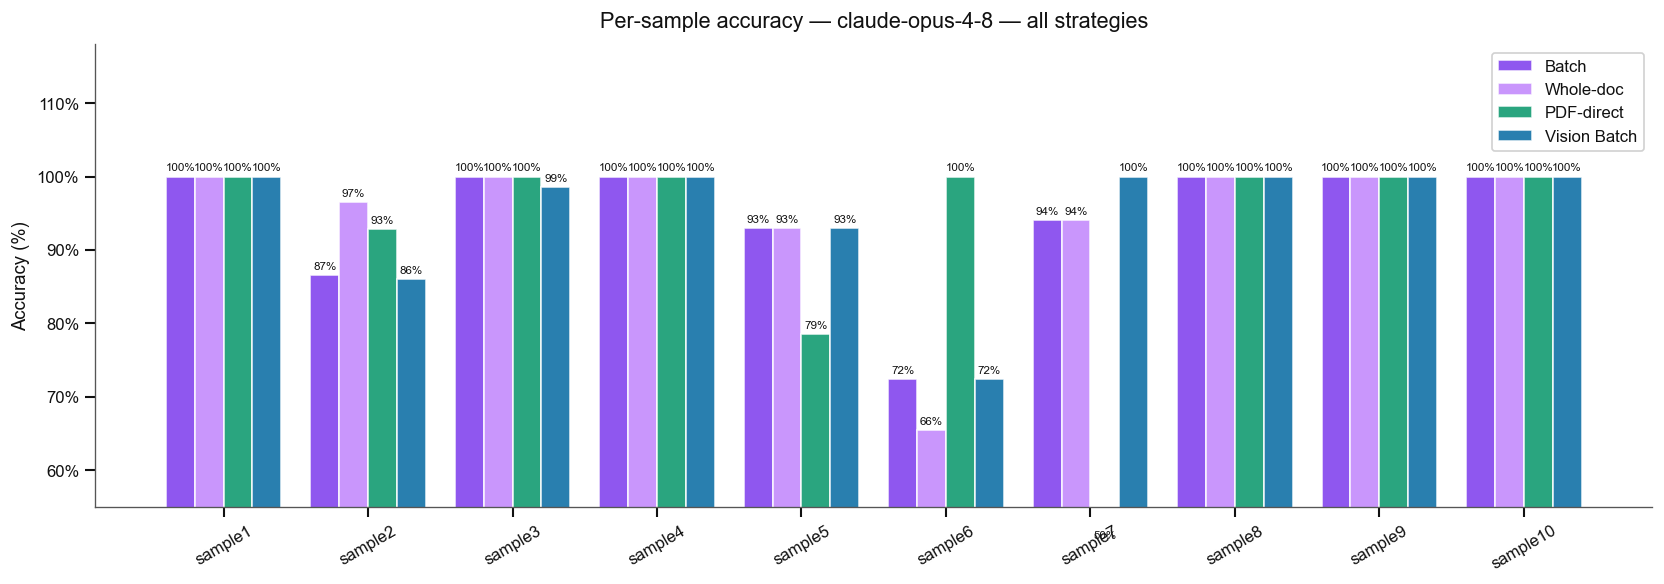

In [10]:
if PDF_AVAILABLE:
    samples_ordered = df_b["sample"].tolist()
    x = range(len(samples_ordered))

    plot_strats = [
        ("Batch",        df_b, COLOR_BATCH,  True),
        ("Whole-doc",    df_w, COLOR_WHOLE,  WHOLEDOC_AVAILABLE),
        ("PDF-direct",   df_p, COLOR_PDF,    True),
        ("Vision Batch", df_v, COLOR_VISION, VISION_AVAILABLE),
    ]
    plot_strats = [(lbl, df, col) for lbl, df, col, flag in plot_strats if flag]
    n_ps = len(plot_strats)
    w    = 0.8 / n_ps

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (lbl, df, color) in enumerate(plot_strats):
        offset = (i - (n_ps - 1) / 2) * w
        acc = df.set_index("sample").reindex(samples_ordered)["accuracy"] * 100
        bars = ax.bar([xi + offset for xi in x], acc, width=w,
                      label=lbl, color=color, alpha=0.85, edgecolor="white")
        for bar, v in zip(bars, acc):
            if not pd.isna(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f"{v:.0f}%", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(list(x)); ax.set_xticklabels(samples_ordered, rotation=30)
    ax.set_ylim(55, 118); ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"Per-sample accuracy — {MODEL_NAME} — all strategies", pad=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(framealpha=0.9); sns.despine(); plt.tight_layout(); plt.show()


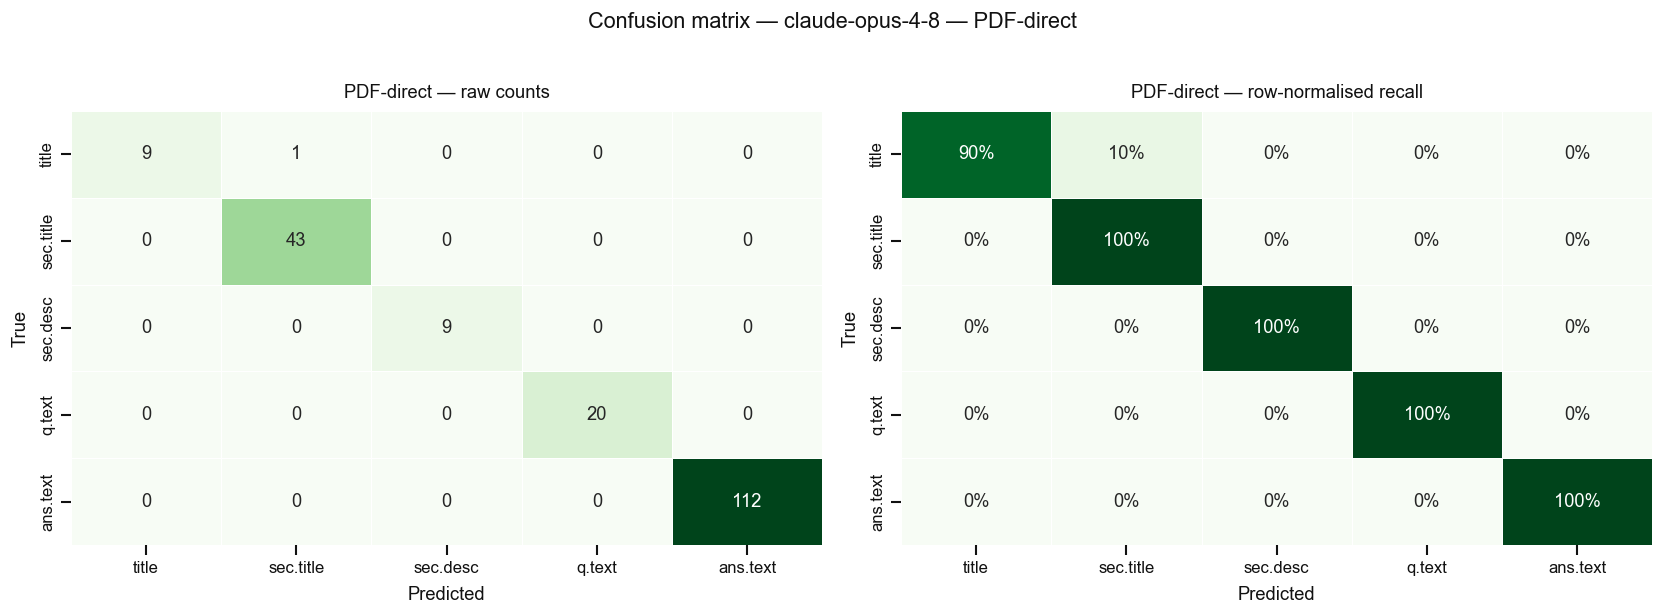

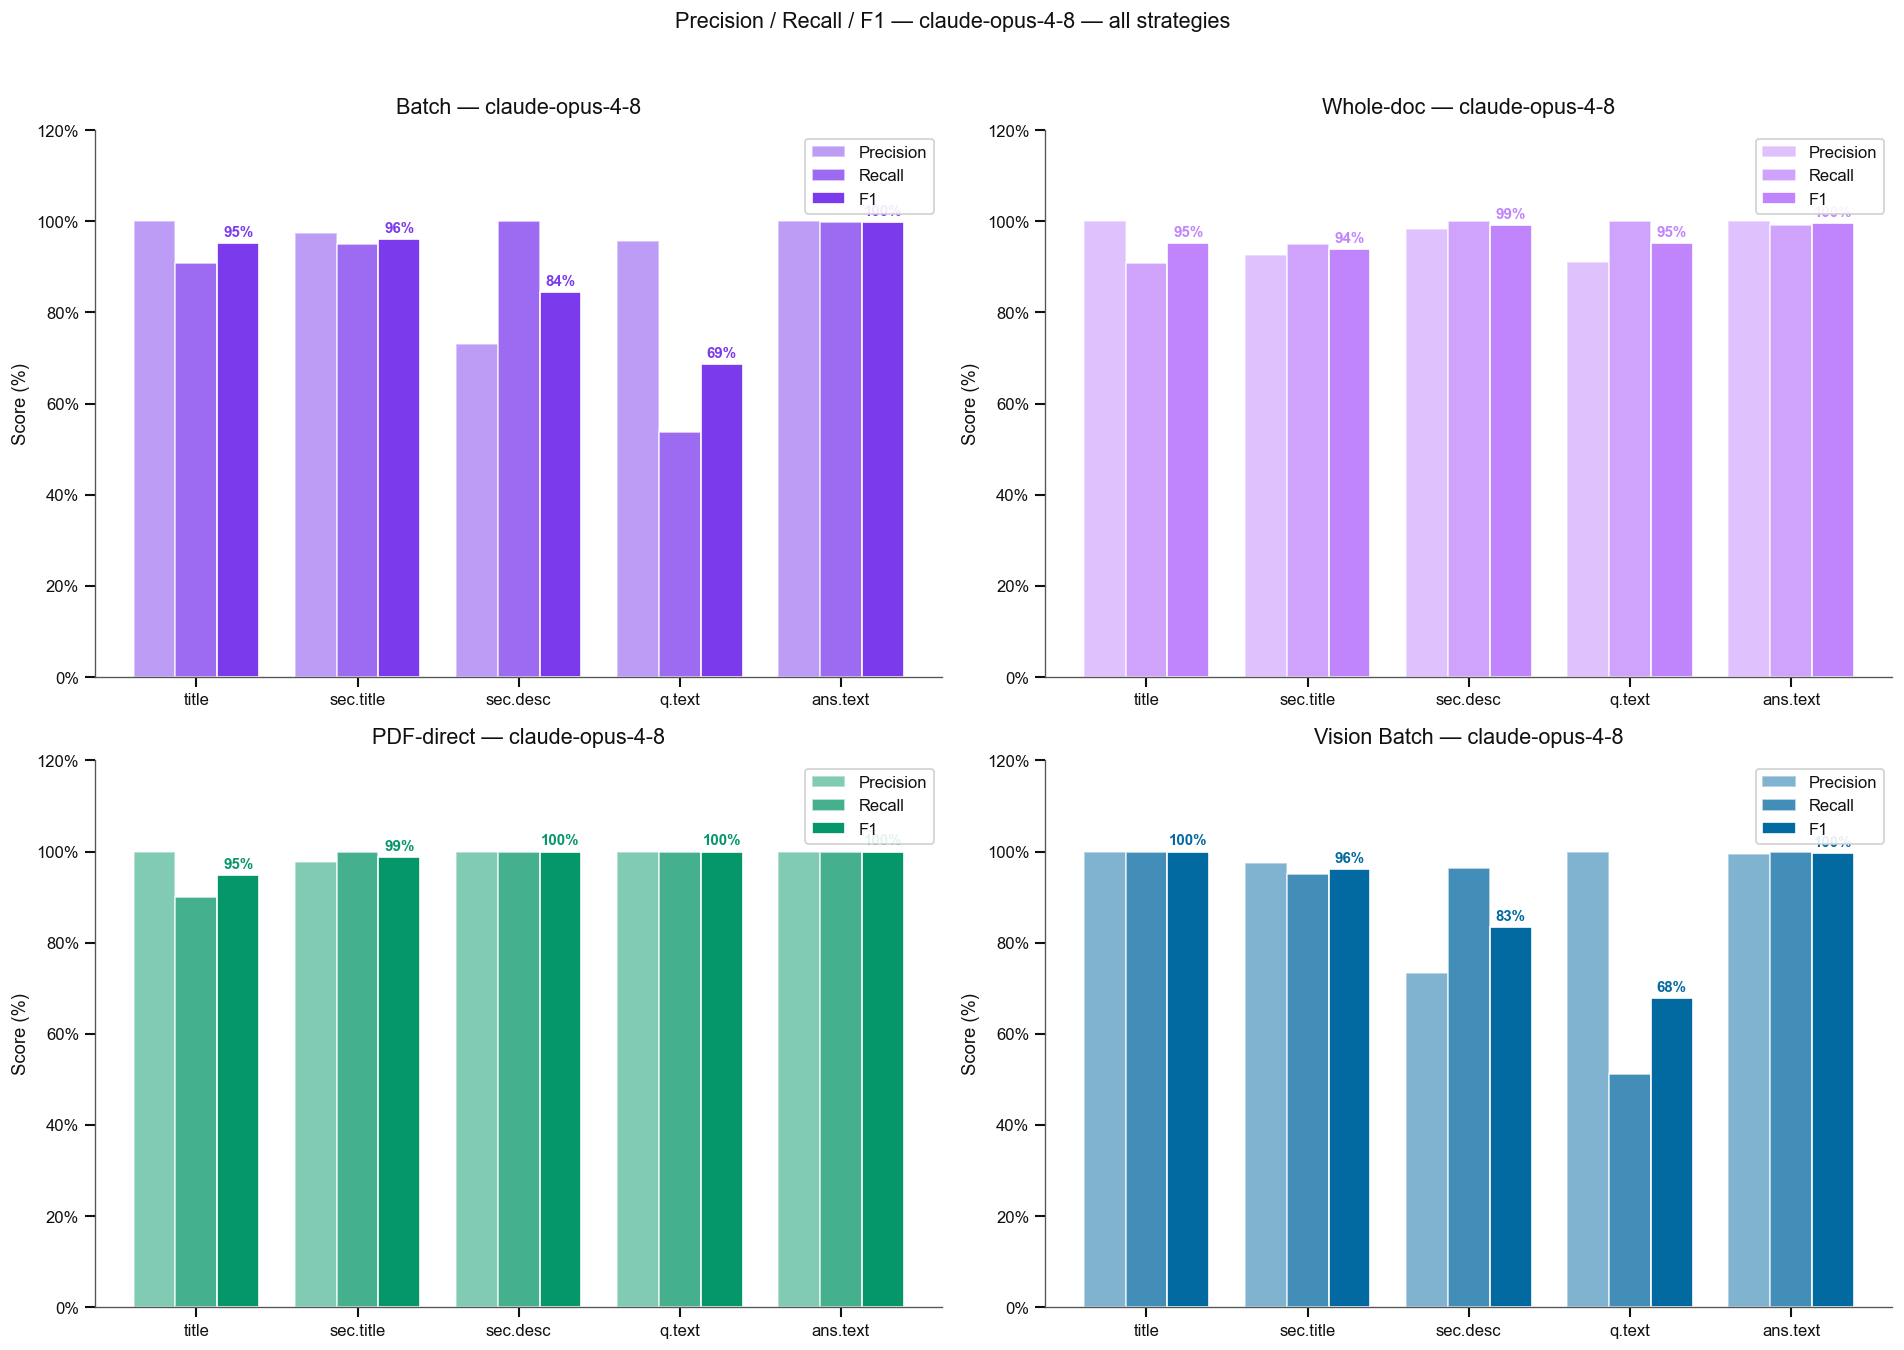

,batch,whole-doc,Δ whole,pdf-direct,Δ pdf,vision-batch,Δ vision
label,,,,,,,
title,95.2%,95.2%,0.0%,94.7%,-0.5%,100.0%,4.8%
section.title,96.2%,93.8%,-2.4%,98.9%,2.6%,96.2%,0.0%
section.description,84.4%,99.1%,14.7%,100.0%,15.6%,83.3%,-1.1%
question.text,68.8%,95.3%,26.6%,100.0%,31.2%,67.7%,-1.0%
answer.text,99.9%,99.6%,-0.3%,100.0%,0.1%,99.7%,-0.2%


In [11]:
if PDF_AVAILABLE:
    mat_p, mat_pn = conf_to_df(conf_p)

    # ── Confusion matrix — PDF-direct ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mat, fmt, title in [
        (axes[0], mat_p,  "d",   "PDF-direct — raw counts"),
        (axes[1], mat_pn, ".0%", "PDF-direct — row-normalised recall"),
    ]:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap=CMAP_PDF, linewidths=0.6,
                    linecolor="white", ax=ax, cbar=False, annot_kws={"size": 11},
                    vmin=(0 if fmt == ".0%" else None), vmax=(1 if fmt == ".0%" else None))
        ax.set_title(title, pad=8, fontsize=11)
        ax.set_xlabel("Predicted", labelpad=6); ax.set_ylabel("True", labelpad=6)
    plt.suptitle(f"Confusion matrix — {MODEL_NAME} — PDF-direct", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    # ── F1 — all strategies (2x2 grid) ───────────────────────────────────
    df_f1_b_ = compute_f1_rows(conf_b)
    df_f1_w_ = compute_f1_rows(conf_w) if WHOLEDOC_AVAILABLE else None
    df_f1_p  = compute_f1_rows(conf_p)
    df_f1_v_ = compute_f1_rows(conf_v) if VISION_AVAILABLE   else None

    all_f1 = [
        (df_f1_b_, COLOR_BATCH,  f"Batch — {MODEL_NAME}"),
        (df_f1_w_, COLOR_WHOLE,  f"Whole-doc — {MODEL_NAME}"),
        (df_f1_p,  COLOR_PDF,    f"PDF-direct — {MODEL_NAME}"),
        (df_f1_v_, COLOR_VISION, f"Vision Batch — {MODEL_NAME}"),
    ]
    all_f1 = [(df, col, title) for df, col, title in all_f1 if df is not None]

    n_f = len(all_f1)
    ncols = 2; nrows = (n_f + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5.5 * nrows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, (df_f1, color, title) in zip(axes_flat, all_f1):
        xi, bw = range(len(LABELS)), 0.26
        ax.bar([i - bw for i in xi], df_f1["precision"]*100, width=bw,
               label="Precision", color=color, alpha=0.5, edgecolor="white")
        ax.bar([i      for i in xi], df_f1["recall"]*100,    width=bw,
               label="Recall",    color=color, alpha=0.75, edgecolor="white")
        bars = ax.bar([i + bw for i in xi], df_f1["f1"]*100, width=bw,
                      label="F1", color=color, edgecolor="white")
        for bar, row in zip(bars, df_f1.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                    f"{row.f1*100:.0f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color=color)
        ax.set_xticks(list(xi)); ax.set_xticklabels(SHORT, fontsize=10)
        ax.set_ylim(0, 120); ax.set_ylabel("Score (%)"); ax.set_title(title, pad=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
        ax.legend(loc="upper right", framealpha=0.9); sns.despine(ax=ax)

    for ax in axes_flat[n_f:]:
        ax.set_visible(False)

    plt.suptitle(f"Precision / Recall / F1 — {MODEL_NAME} — all strategies", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    # ── F1 delta table: all strategies vs batch ───────────────────────────
    comb = df_f1_b_.set_index("label")[["f1"]].rename(columns={"f1":"batch"})
    if df_f1_w_ is not None:
        comb["whole-doc"]    = df_f1_w_.set_index("label")["f1"].values
        comb["Δ whole"]      = comb["whole-doc"] - comb["batch"]
    comb["pdf-direct"]       = df_f1_p.set_index("label")["f1"].values
    comb["Δ pdf"]            = comb["pdf-direct"] - comb["batch"]
    if df_f1_v_ is not None:
        comb["vision-batch"] = df_f1_v_.set_index("label")["f1"].values
        comb["Δ vision"]     = comb["vision-batch"] - comb["batch"]
    score_cols = [c for c in comb.columns if not c.startswith("Δ")]
    display(comb.style.format("{:.1%}").background_gradient(subset=score_cols, cmap="Blues"))


In [12]:
if PDF_AVAILABLE:
    print("=== Mislabeled blocks — PDF-direct ===\n")
    error_breakdown(errs_p, f"PDF-direct — {MODEL_NAME}")

    if not errs_p.empty:
        pd.set_option("display.max_colwidth", 100)
        display(errs_p[["sample", "page", "true", "pred", "text"]])

=== Mislabeled blocks — PDF-direct ===

  PDF-direct — claude-opus-4-8: 1 mislabeled blocks
 true          pred  count
title section.title      1



,sample,page,true,pred,text
0,sample7,1,title,section.title,Resource/Data Sharing Plan


---

## 7 — Vision Batch

pdfplumber extracts line-level blocks with bounding boxes and font metadata.  
Each page is rendered as a PNG at 150 DPI and sent to Claude alongside the blocks for that page.  
Claude uses the **visual layout** (font size hierarchy, bold rendering, spacing) together with the structured text to classify each block.

**Images saved to:** `data/output/page_images/sampleN/page_NNN.png` (reusable across models)  
**Regenerate:** `dmpbridge-experiment experiments/claude-opus-4-8-vision.yaml`


=== Four-strategy accuracy comparison ===

  Strategy          Blocks   Correct   Accuracy
  ---------------------------------------------
  Batch                741       703      94.9%
  Whole-doc            741       718      96.9%
  PDF-direct           203       193      95.1%
  Vision Batch         741       702      94.7%


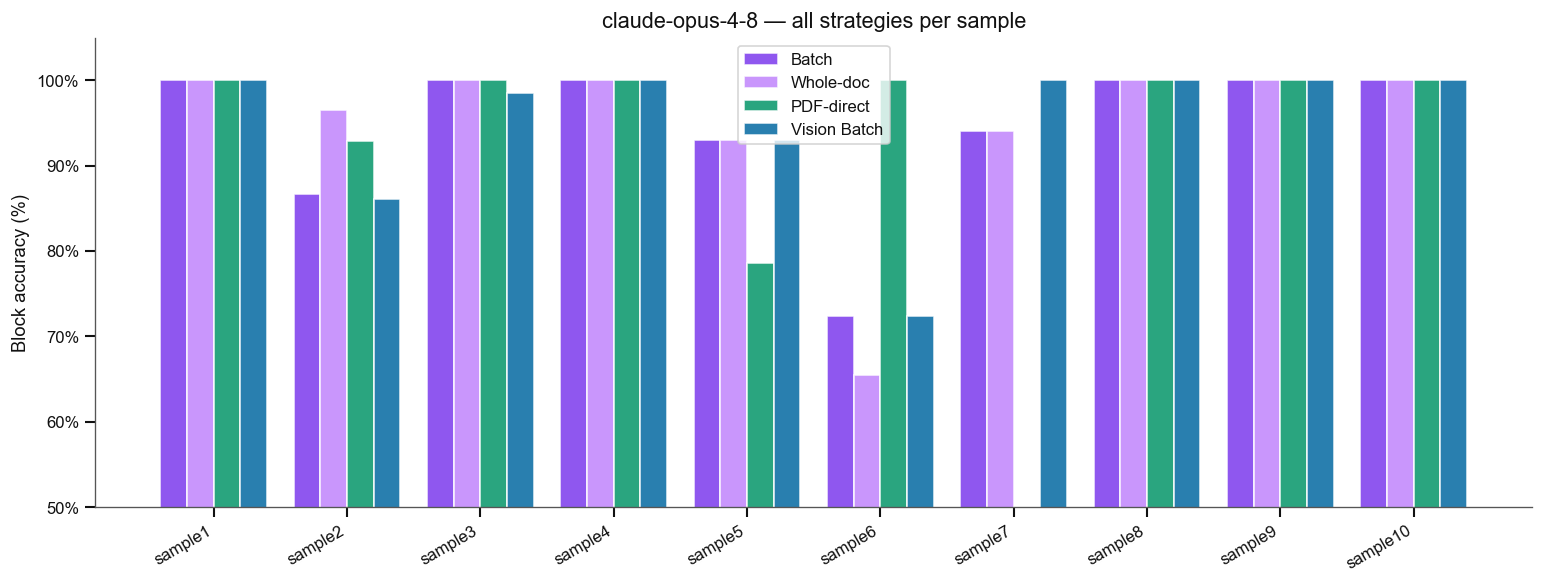

In [13]:
if VISION_AVAILABLE:
    # ── Four-way accuracy comparison ─────────────────────────────────────
    print("=== Four-strategy accuracy comparison ===\n")
    strategies = [
        ("Batch",        df_b, COLOR_BATCH),
        ("Whole-doc",    df_w, COLOR_WHOLE),
        ("PDF-direct",   df_p, COLOR_PDF),
        ("Vision Batch", df_v, COLOR_VISION),
    ]
    hdr = f"  {'Strategy':<14}  {'Blocks':>8}  {'Correct':>8}  {'Accuracy':>9}"
    print(hdr)
    print('  ' + '-' * (len(hdr) - 2))
    for label, df, _ in strategies:
        if df is None or df.empty: continue
        tc_ = int(df['correct'].sum())
        tn_ = int(df['total'].sum())
        print(f"  {label:<14}  {tn_:>8}  {tc_:>8}  {tc_/tn_*100:>8.1f}%")

    # ── Per-sample accuracy chart ─────────────────────────────────────────
    samples = df_b['sample'].tolist()
    x = range(len(samples))
    w = 0.2
    fig, ax = plt.subplots(figsize=(13, 5))
    acc_b = df_b.set_index('sample')['accuracy']
    acc_v = df_v.set_index('sample')['accuracy']
    ax.bar([xi - 1.5*w for xi in x], [acc_b.get(s, 0)*100 for s in samples],
           w, label='Batch', color=COLOR_BATCH, alpha=0.85)
    if WHOLEDOC_AVAILABLE:
        acc_w = df_w.set_index('sample')['accuracy']
        ax.bar([xi - 0.5*w for xi in x], [acc_w.get(s, 0)*100 for s in samples],
               w, label='Whole-doc', color=COLOR_WHOLE, alpha=0.85)
    if PDF_AVAILABLE:
        acc_p = df_p.set_index('sample')['accuracy']
        ax.bar([xi + 0.5*w for xi in x], [acc_p.get(s, 0)*100 for s in samples],
               w, label='PDF-direct', color=COLOR_PDF, alpha=0.85)
    ax.bar([xi + 1.5*w for xi in x], [acc_v.get(s, 0)*100 for s in samples],
           w, label='Vision Batch', color=COLOR_VISION, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(samples, rotation=30, ha='right')
    ax.set_ylabel('Block accuracy (%)')
    ax.set_title(f'{MODEL_DISPLAY} — all strategies per sample')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylim(50, 105)
    ax.legend()
    sns.despine(ax=ax)
    plt.tight_layout(); plt.show()
else:
    print('Vision data not available — run: dmpbridge-experiment experiments/claude-opus-4-8-vision.yaml')


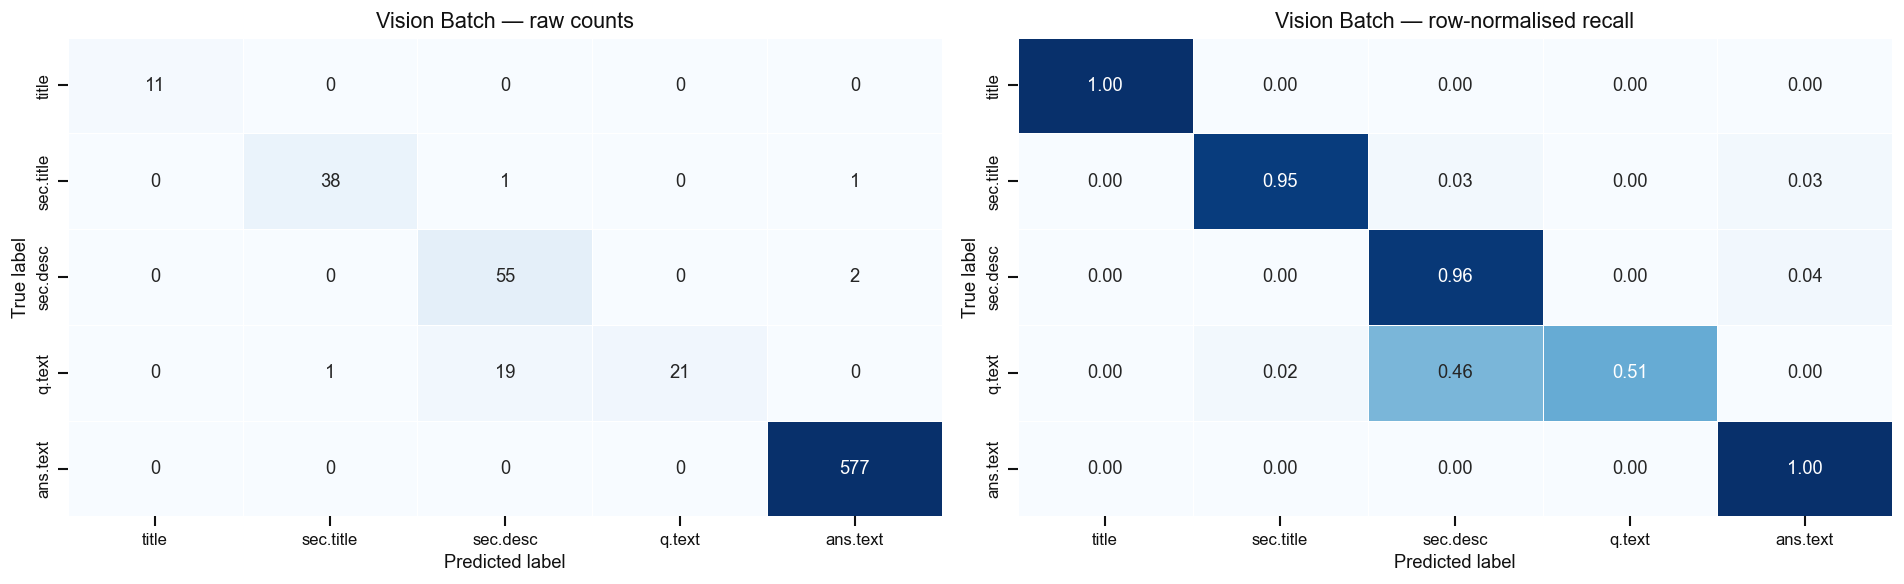

In [14]:
if VISION_AVAILABLE:
    mat_v, mat_vn = conf_to_df(conf_v)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(mat_v,  annot=True, fmt='d',  cmap=CMAP_VISION, ax=axes[0],
                linewidths=0.5, cbar=False)
    axes[0].set_title('Vision Batch — raw counts')
    axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')
    sns.heatmap(mat_vn, annot=True, fmt='.2f', cmap=CMAP_VISION, ax=axes[1],
                linewidths=0.5, cbar=False, vmin=0, vmax=1)
    axes[1].set_title('Vision Batch — row-normalised recall')
    axes[1].set_ylabel('True label'); axes[1].set_xlabel('Predicted label')
    plt.tight_layout(); plt.show()


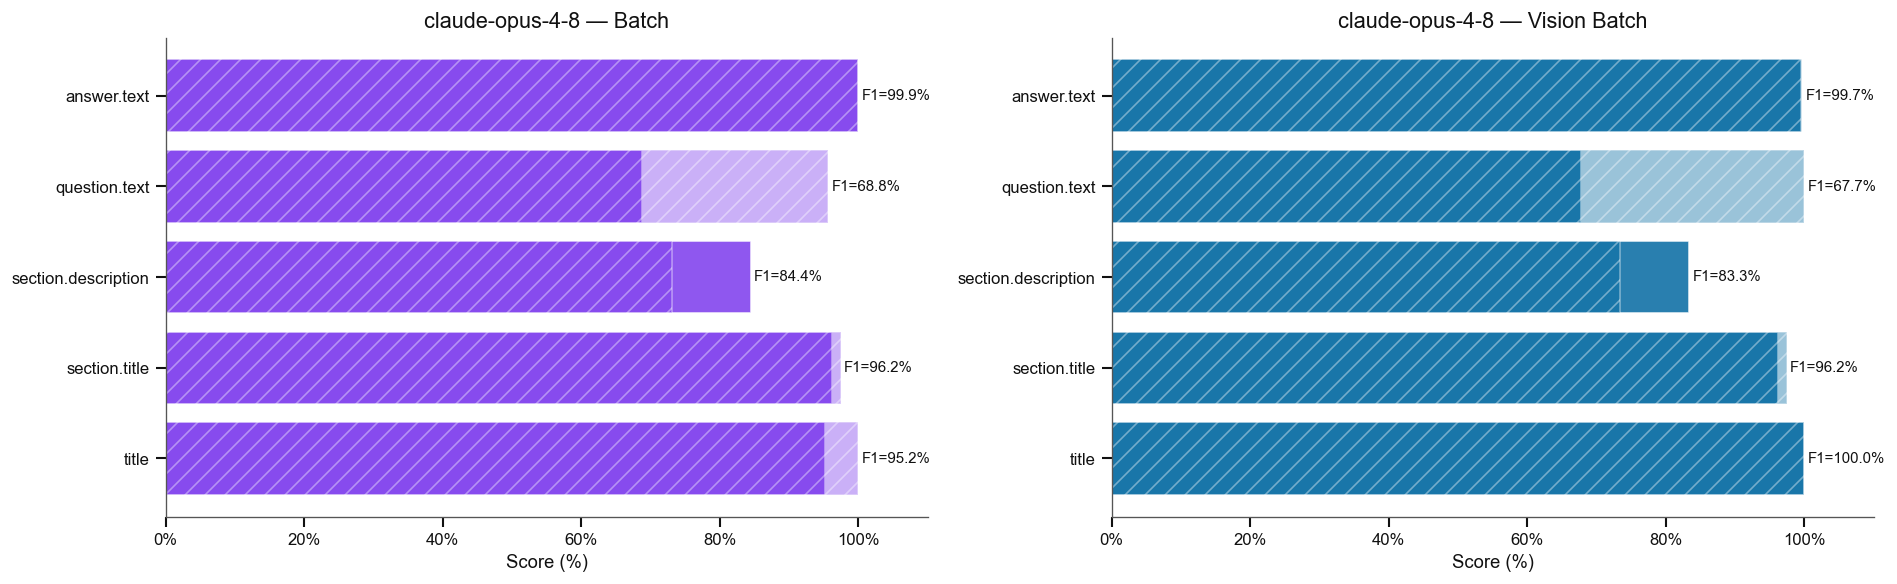


=== Vision Batch — F1 table ===



,label,precision,recall,f1,support
0,title,100.0%,100.0%,100.0%,11
1,section.title,97.4%,95.0%,96.2%,40
2,section.description,73.3%,96.5%,83.3%,57
3,question.text,100.0%,51.2%,67.7%,41
4,answer.text,99.5%,100.0%,99.7%,577


In [15]:
if VISION_AVAILABLE:
    df_f1_v = compute_f1_rows(conf_v)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    panels = [
        (axes[0], df_f1_b, COLOR_BATCH,  'Batch'),
        (axes[1], df_f1_v, COLOR_VISION, 'Vision Batch'),
    ]
    for ax, df_f1, color, title in panels:
        ax.barh(df_f1['label'], df_f1['f1']*100, color=color, alpha=0.85)
        ax.barh(df_f1['label'], df_f1['precision']*100,
                color=color, alpha=0.4, hatch='//', label='Precision')
        for i, (f, pr, rc) in enumerate(zip(df_f1['f1'], df_f1['precision'], df_f1['recall'])):
            ax.text(max(f, pr)*100 + 0.5, i, f'F1={f*100:.1f}%', va='center', fontsize=9)
        ax.set_xlim(0, 110); ax.set_xlabel('Score (%)')
        ax.set_title(f'{MODEL_DISPLAY} — {title}')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
        sns.despine(ax=ax)
    plt.tight_layout(); plt.show()

    print('\n=== Vision Batch — F1 table ===\n')
    df_f1_v_disp = df_f1_v.copy()
    for col in ['precision','recall','f1']:
        df_f1_v_disp[col] = df_f1_v_disp[col].map('{:.1%}'.format)
    display(df_f1_v_disp)


In [16]:
if VISION_AVAILABLE:
    print('=== Mislabeled blocks — Vision Batch ===\n')
    error_breakdown(errs_v, f'Vision Batch — {MODEL_NAME}')
    if not errs_v.empty:
        pd.set_option('display.max_colwidth', 100)
        display(errs_v[['sample','page','true','pred','text']])


=== Mislabeled blocks — Vision Batch ===

  Vision Batch — claude-opus-4-8: 27 mislabeled blocks
               true                pred  count
      question.text section.description     19
           no_match         answer.text      3
section.description         answer.text      2
      question.text       section.title      1
      section.title         answer.text      1
      section.title section.description      1



,sample,page,true,pred,text
0,sample2,2,question.text,section.title,Data Sharing and Data Preservation. A description of the plans for data sharing and preservation.
1,sample2,2,question.text,section.description,"This should include, where appropriate:"
2,sample2,2,question.text,section.description,the anticipated means for sharing and rationale for any restrictions on who may access the data
3,sample2,2,question.text,section.description,and under what conditions;
4,sample2,2,question.text,section.description,a timeline for sharing and preservation that addresses both the minimum length of time the data
5,sample2,2,question.text,section.description,will be available and any anticipated delay to data access after research findings are published;
6,sample2,2,question.text,section.description,"any special requirements for data sharing, for example, proprietary software needed to access"
7,sample2,2,question.text,section.description,"or interpret data, applicable policies, provisions, and licenses for re-use and re-distribution,..."
8,sample2,2,question.text,section.description,"for the production of derivatives, including guidance for how data and data products should be"
9,sample2,2,question.text,section.description,cited;
